In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Research Question: Can snacking behavior offset the benefits of healthy habits such as physical activity, low calorie meals, and vegetable consumption in relation to obesity?

1. Load the dataset with Pandas 

Read your dataset from a file (CSV, JSON, Excel, etc.) using pandas. Print the shape and display the first few rows. Handle any obvious loading issues (encoding, separators, missing headers).

In [ ]:
#Source: UCI Machine Learning Repository 
#investigates obesity levels in individuals from the countries of Mexico, Peru and Colombia, based on their eating habits and physical condition
#2111 instances, 16 features

data = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')
data.head()



,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [4]:
data.shape

(2111, 17)

2. A for loop with a running counter

Write a for loop that does something meaningful related to your dataset or analysis. The loop must maintain a running counter that tracks something across iterations — not just enumerate for its own sake. Clearly comment what the counter is accumulating and why.

For example: Loop over a number of samples from your dataset and count how many yield a test-statistic above a threshold. Or, loop over columns and count how many have more than 5% missing values, or a value above a threshold.

In [ ]:
#This code was used to get a baseline understanding of snacking behavior in the dataset. 
# It counts how many individuals frequently snack and how many of those individuals are classified as obese. 
# This helps establish whether there is any general relationship between frequent snacking and obesity
# before focusing specifically on healthy individuals.

snacking_count = 0
snacking_obese_count = 0

#loop tracks how many people frequently snack and how many of those are obese
for i in range(len(data)):
    
    if data.loc[i, "CAEC"] in ["Frequently", "Always"]: #frequent snacking is defined as "Frequently" or "Always" in the CAEC column
        snacking_count += 1
        
        if data.loc[i, "NObeyesdad"] in ["Obesity_Type_I", "Obesity_Type_II", "Obesity_Type_III"]: #obesity is defined as any of the three obesity types in the NObeyesdad column
            snacking_obese_count += 1

print("Total frequent snackers:", snacking_count)
print("Frequent snackers who are obese:", snacking_obese_count)

Total frequent snackers: 295
Frequent snackers who are obese: 16


3. Conditional logic

Use an if / elif / else block somewhere in your analysis. It must branch on a real condition — not a hardcoded constant. Label your if/else/elif branch with a comment.

For example: apply different preprocessing steps depending on a column's data type

In [ ]:
#this code provides a general overview of the relationship between frequent snacking and obesity in the dataset, 
# which can inform further analysis focused specifically on healthy individuals. using an if/elif/else structure, the code categorizes individuals into 
# three groups: healthy snackers, healthy non-snackers, and not healthy. Healthy individuals are defined as those with FCVC >= 2, FAF > 1, and FAVC == "no".

#FAF = physical acitivity
#FCVC = vegetable consumption
#FAVC = consumption of high calorie food


healthy_snacking = 0
healthy_no_snacking = 0
not_healthy = 0

for i in range(len(data)):
    
    #if branch: healthy AND snacking
    if (
        data.loc[i, "FCVC"] >= 2 and 
        data.loc[i, "FAF"] > 1 and 
        data.loc[i, "FAVC"] == "no" and
        data.loc[i, "CAEC"] in ["Frequently", "Always"] #frequent snacking is defined as "Frequently" or "Always" in the CAEC column
    ):
        healthy_snacking += 1
    
    #elif branch: healthy but NOT snacking
    elif (
        data.loc[i, "FCVC"] >= 2 and 
        data.loc[i, "FAF"] > 1 and 
        data.loc[i, "FAVC"] == "no"
    ):
        healthy_no_snacking += 1
    
    #else branch: not healthy
    else:
        not_healthy += 1

print("Healthy + snacking:", healthy_snacking)
print("Healthy + no snacking:", healthy_no_snacking)
print("Not healthy:", not_healthy)

Healthy + snacking: 45
Healthy + no snacking: 67
Not healthy: 1999


4. Write and call your own function

Define at least one function that takes parameters and returns a value. The function must do something meaningful with your dataset — not just wrap a single built-in call. Call it at least twice with different arguments and print the result. Your function must include a docstring!

In [ ]:
#function to classify individuals based on healthy behavior and snacking habits. you can enter parameters for FCVC, FAF, FAVC, and CAEC
#  to get a classification of 'healthy_snacking', 'healthy_no_snacking', or 'not_healthy'.

def classify_person(fcvc, faf, favc, caec):
    """
    classifies an individual based on healthy behavior and snacking habits.
    returns 'healthy_snacking', 'healthy_no_snacking', or 'not_healthy'.
    parameters:
    - fcvc: frequency of vegetable consumption (numeric)
    - faf: frequency of physical activity (numeric)
    - favc: consumption of fruits and vegetables (categorical: "yes", "no")
    - caec: consumption of food between meals (categorical: "Frequently", "Always")
    """
    
    if fcvc >= 2 and faf > 1 and favc == "no" and caec in ["Frequently", "Always"]:
        return "healthy_snacking"
    
    elif fcvc >= 2 and favc == "no" and faf > 1:
        return "healthy_no_snacking"
    
    else:
        return "not_healthy"

In [8]:
print(classify_person(0, 2, "no", "Frequently"))   
print(classify_person(3, 2, "yes", "Sometimes"))   

not_healthy
not_healthy


5. Numpy array indexing
Extract at least one column (or derived values) into a numpy array. Perform at least two of the following:

Vectorized operations (e.g. mean, sum, etc)
Boolean masking of values
Index access to retrieve a specific element
Show that you can work with the array directly!

In [9]:
#exctracted physical activity numpy array 
faf_array = data["FAF"].to_numpy()

In [10]:
#Vectorized operation: mean
print("Average physical activity:", np.mean(faf_array))

Average physical activity: 1.0102976958787304


In [ ]:
#boolean masking
high_activity = faf_array[faf_array > 2]

print("Number of high activity people:", len(high_activity))

#This code uses NumPy boolean masking to identify individuals with high physical activity levels 
# and count how many there are. This helps quantify how common higher activity levels are in the 
# dataset.

Number of high activity people: 193


6. Dictionary manipulation

Build your own dictionary to store results across iterations, then read from it (using a for loop or read directly using square brackets).

Example: Loop over categories of your dataset, compute a summary statistic for each, and store it in a dict. Then, read the dict to identify which category had the highest value.

In [ ]:
#looked to see if there was a relationship between healthy snacking and obesity. the code counts how many healthy snackers and healthy non-snackers are obese,
#  then calculates the obesity percentage for each group.

#we found that healthy + no snacking were more likely to be obese than healthy + snacking, which suggests that snacking behavior alone may not determine obesity risk, and other
# factors such as overall calorie intake or meal size may play a larger role.

results = {
    "healthy_snacking": {"total": 0, "obese": 0},
    "healthy_no_snacking": {"total": 0, "obese": 0}
}

for i in range(len(data)):
    
    if ( #chekcs if person is healthy based on FCVC, FAF, and FAVC, then checks if they are a frequent snacker based on CAEC
        data.loc[i, "FCVC"] >= 2 and 
        data.loc[i, "FAF"] > 1 and
        data.loc[i, "FAVC"] == "no"
    ):
        
        if data.loc[i, "CAEC"] in ["Frequently", "Always"]:
            results["healthy_snacking"]["total"] += 1 #adds to total count of healthy snackers
            
            if data.loc[i, "NObeyesdad"] in ["Obesity_Type_I", "Obesity_Type_II", "Obesity_Type_III"]:
                results["healthy_snacking"]["obese"] += 1 #adds to count of obese healthy snackers
        
        else:
            results["healthy_no_snacking"]["total"] += 1 #adds to total count of healthy non-snackers
            
            if data.loc[i, "NObeyesdad"] in ["Obesity_Type_I", "Obesity_Type_II", "Obesity_Type_III"]:
                results["healthy_no_snacking"]["obese"] += 1 #adds to count of obese healthy non-snackers

for group in results: #calculates and prints obesity percentage for each group
    total = results[group]["total"]
    obese = results[group]["obese"]
    
    if total > 0:
        print(group, "obesity percentage:", (obese / total) * 100)

healthy_snacking obesity percentage: 2.2222222222222223
healthy_no_snacking obesity percentage: 7.462686567164178


7. Two plots with matplotlib

Produce at least two distinct plots using matplotlib. Every plot must have axis labels and a title.

Plot 1 (required): a histogram of a numeric column. Choose a meaningful bin count and label the axes with units. Comment on the shape of your data (Gaussian? Binominal? Other distribution?).
Plot 2 (your choice): any other plot type relevant to your data — scatter, bar, line, box plot, etc. Briefly explain in a comment or markdown cell why you chose this plot for your data.


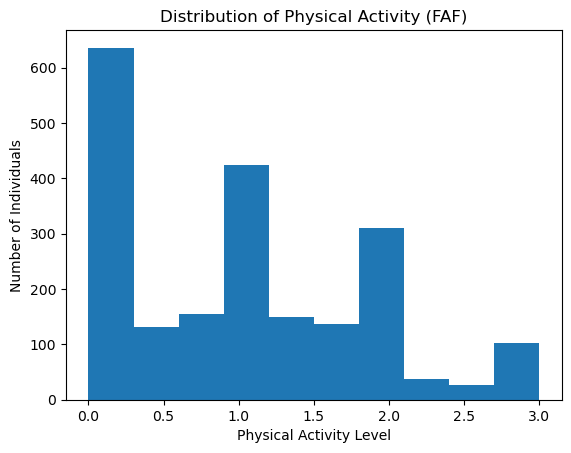

In [ ]:
#we wanted to look at physical activity because it is a key component of a healthy lifestyle and could ahve a significant impact on obesity risk. 
#Snacking behavior alone may not determine obesity risk, so I wanted to see how physical activity levels are distributed in the dataset to better understand 
# the context of physical activity among the individuals.

plt.hist(data["FAF"], bins=10)
plt.title("Distribution of Physical Activity (FAF)")
plt.xlabel("Physical Activity Level")
plt.ylabel("Number of Individuals")

plt.show()

#right skewed distribution of physical activity levels, with most people having low FAF values and fewer people having high FAF values.

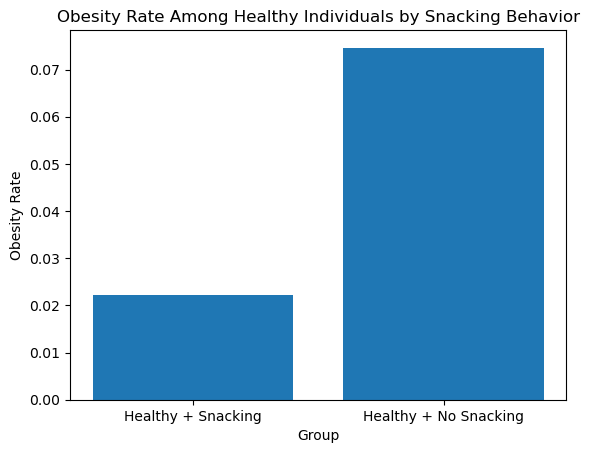

In [ ]:
snacking_rate = results["healthy_snacking"]["obese"] / results["healthy_snacking"]["total"]
no_snacking_rate = results["healthy_no_snacking"]["obese"] / results["healthy_no_snacking"]["total"]
groups = ["Healthy + Snacking", "Healthy + No Snacking"]
rates = [snacking_rate, no_snacking_rate]

plt.bar(groups, rates)

plt.title("Obesity Rate Among Healthy Individuals by Snacking Behavior")
plt.xlabel("Group")
plt.ylabel("Obesity Rate")

plt.show()


#chose bar graph because it allows for easy comparison of obesity rates between the two groups of healthy individuals (those who snack frequently and those who do not). 
# The graph visually highlights the difference in obesity rates, making it easier to interpret the 
# relationship between snacking behavior and obesity risk among healthy individuals.


#Interestingly, the obesity rate was higher among healthy individuals who did not snack compared to 
# those who did. This suggests that snacking behavior alone may not determine obesity risk, and other
# factors such as overall calorie intake or meal size may play a larger role.

8. A more advanced task: a simulation loop OR linear regression.

In this final task, you have a choice. You may either:

Test a hypothesis with sample permutation. Write a 1-sentence interpretation of your p-value in the context of your dataset topic.
Example: In class, we took a Penguin dataset to test whether one species of Penguins was heavier than other. We first computed the absolute difference in weight (observed). Then, we ran simulations (where we shuffled the labels 1000 times) and we computed and printed the p-value. Finally, we interpreted that p-value to see if we can reject the null hypothesis.

Perform a linear regression or a fit to features in your data. Compute a metric that assess the quality of your fit. Write a 1-sentence interpretation of the result.


In [ ]:
#created a new column "obese" that is 1 if the person is classified as any of the three obesity types in the NObeyesdad column, and 0 otherwise.
data["obese"] = data["NObeyesdad"].isin(
    ["Obesity_Type_I", "Obesity_Type_II", "Obesity_Type_III"]
).astype(int)

In [ ]:
#created a new column "snacking_num" that converts the categorical snacking behavior in the CAEC column to numeric 
data["snacking_num"] = data["CAEC"].map({
    "no": 0,
    "Sometimes": 1,
    "Frequently": 2,
    "Always": 3
})

In [ ]:
#created a new column "favc_num" that converts the categorical consumption of high calorie food in the FAVC column to numeric
data["favc_num"] = data["FAVC"].map({
    "no": 0,
    "yes": 1
})

In [23]:
from sklearn.linear_model import LinearRegression

X = data[["FAF", "FCVC", "snacking_num", "favc_num"]]
y = data["obese"]

model = LinearRegression()
model.fit(X, y)

print("R^2:", model.score(X, y))
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

#plot predicted obesity probabilities based on the model for different levels of snacking behavior, while holding other variables constant


R^2: 0.16590189580138925
Intercept: 0.007526796186168583
Coefficients: [-0.06969024  0.18200271 -0.21689789  0.37385696]


The regression model had an R² value of 0.166, indicating that physical activity, vegetable intake, snacking behavior, and high-calorie food consumption explain a small portion of the variation in obesity.